In [1]:
# Instala os pacotes necessários
!pip install feature-engine
!pip install catboost

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Importa as bibliotecas
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from feature_engine.selection import SmartCorrelatedSelection # Para seleção de features correlacionadas
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn import set_config # Usado para configurar as configurações globais do scikit-learn
from sklearn.base import clone # Usado para clonar estimadores
from sklearn.base import BaseEstimator, TransformerMixin # Classes base para transformadores customizados

from itertools import combinations # Para criar interações entre features
from scipy.stats import pointbiserialr # Para calcular a correlação ponto-bisserial

# Configura o pandas para exibir todas as colunas
pd.set_option('display.max_columns', None)
# Configura o scikit-learn para que os transformadores retornem DataFrames do pandas
set_config(transform_output='pandas')

In [3]:
# Define constantes para caminhos de arquivo e semente aleatória
ROOT = "/content/drive/MyDrive/ml-project" # Diretório raiz do projeto (atualize se necessário)
FILE = "smart-contract-dataset.csv" # Nome do arquivo do dataset
SEED = 78 # Semente aleatória para reprodutibilidade

In [4]:
# Carrega o dataset
# Assume que o arquivo CSV está no mesmo diretório que o notebook,
# ou o caminho ROOT precisa ser usado se o arquivo estiver em outro local.
# data = pd.read_csv(os.path.join(ROOT, FILE)) # Descomente se o arquivo estiver no ROOT
data = pd.read_csv(FILE) # Assume que o arquivo está no diretório atual

In [5]:
# Renomeia as colunas para serem mais amigáveis ao Python
# Substitui caracteres especiais por underscores ou representações textuais
data = data.rename(
    columns=lambda col: (
        col
        .replace('<', 'lt') # menor que
        .replace('>', 'gt') # maior que
        .replace('__', '_double_underscore') # underscore duplo
        .replace(':', '_colon') # dois pontos
    )
)

In [6]:
# Separa as features (X) e o alvo (y)
# Seleciona todas as colunas numéricas a partir da 4ª coluna como features
X = data.iloc[:, 3:].select_dtypes(include="number")
# Seleciona a coluna 'label' como a variável alvo
y = data.label

In [7]:
# Divide os dados em conjuntos de treinamento/validação e teste
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y # 20% para o conjunto de teste, estratificado por y
)

# Divide o conjunto de treinamento/validação em conjuntos de treinamento e validação
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=SEED, stratify=y_train_val # 20% do train_val para o conjunto de validação, estratificado
)

# Imprime as dimensões dos datasets resultantes
print("Dimensões dos conjuntos:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

Dimensões dos conjuntos:
X_train: (23468, 263), y_train: (23468,)
X_val:   (5868, 263), y_val:   (5868,)
X_test:  (7335, 263), y_test:  (7335,)


## Definição de Transformadores Customizados
#### Nesta seção, definimos classes customizadas que herdam de `BaseEstimator` e `TransformerMixin` do scikit-learn.
#### Isso nos permite criar etapas de pré-processamento personalizadas que podem ser integradas em pipelines do scikit-learn.
### `TreeFeatureSelector`
#### Este transformador utiliza uma `DecisionTreeClassifier` para identificar as features mais importantes.
#### Ele treina uma árvore de decisão nos dados e seleciona as `k` features com as maiores importâncias.
### `SelectiveInteraction`
#### Este transformador cria novas features de interação (produto de pares de features).
#### A seleção dos pares para interação é baseada na correlação ponto-bisserial de cada feature com a variável alvo (binária).
#### Apenas features com correlação (em módulo) acima de um `threshold` e com sinais opostos de correlação com o alvo são consideradas para criar interações.
#### Isso visa capturar relações onde, por exemplo, uma feature tem correlação positiva com o alvo e outra tem correlação negativa, e a interação delas pode ser informativa.

In [8]:
# Transformador customizado para seleção de features baseada na importância de features de uma Decision Tree
class TreeFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, k=15, random_state=42):
        """
        Inicializa o TreeFeatureSelector.
        Args:
            k (int): Número de features mais importantes a serem selecionadas.
            random_state (int): Semente aleatória para reprodutibilidade da Decision Tree.
        """
        self.k = k
        self.random_state = random_state

    def fit(self, X, y):
        """
        Ajusta o modelo Decision Tree e seleciona as k features mais importantes.
        Args:
            X (pd.DataFrame): Features de entrada.
            y (pd.Series): Variável alvo.
        Returns:
            self: A instância ajustada do transformador.
        """
        self.feature_names_in_ = X.columns # Armazena os nomes das features de entrada
        self.tree_ = DecisionTreeClassifier(random_state=self.random_state)
        self.tree_.fit(X, y)
        importances = self.tree_.feature_importances_
        # Obtém os índices das k features mais importantes (em ordem decrescente de importância)
        indices = np.argsort(importances)[::-1][:self.k]
        self.selected_features_ = self.feature_names_in_[indices] # Armazena os nomes das features selecionadas

        return self

    def transform(self, X):
        """
        Transforma o DataFrame de entrada para manter apenas as features selecionadas.
        Args:
            X (pd.DataFrame): Features de entrada.
        Returns:
            pd.DataFrame: DataFrame contendo apenas as features selecionadas.
        """
        # Verifica se as features selecionadas estão presentes no DataFrame de entrada
        # Isso é uma boa prática para evitar erros se o transformador for usado em dados diferentes
        # dos dados de treinamento, embora o pipeline do scikit-learn geralmente lide com isso.
        return X[self.selected_features_]


# Transformador customizado para criar features de interação seletivamente
class SelectiveInteraction(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.05):
        """
        Inicializa o transformador SelectiveInteraction.
        Args:
            threshold (float): Correlação ponto-bisserial mínima absoluta
                               para uma feature ser considerada para interação.
        """
        self.threshold = threshold
        self.interactions_ = [] # Para armazenar pares de features para interação
        self.feature_corr_ = {} # Para armazenar as correlações calculadas

    def fit(self, X, y):
        """
        Identifica pares de features para interação baseados na sua correlação com o alvo.
        As interações são criadas entre features que têm:
        1. Correlação absoluta com y >= threshold.
        2. Sinais opostos de correlação com y.
        Args:
            X (pd.DataFrame): Features de entrada.
            y (pd.Series): Variável alvo (deve ser binária).
        Returns:
            self: A instância ajustada do transformador.
        """
        # Garante que X e y sejam cópias para evitar modificações nos dados originais
        X_df = pd.DataFrame(X).copy()
        y_series = pd.Series(y).copy()

        # Garante que o alvo seja binário para a correlação ponto-bisserial
        if not set(np.unique(y_series)).issubset({0, 1}):
            raise ValueError("A variável alvo `y` deve ser binária (0/1) para a correlação ponto-bisserial.")

        # Calcula a correlação ponto-bisserial para cada feature com o alvo
        self.feature_corr_ = {
            col: pointbiserialr(X_df[col], y_series)[0]
            for col in X_df.columns
        }

        # Identifica pares de features para interação
        self.interactions_ = [
            (f1, f2)
            for f1, f2 in combinations(X_df.columns, 2) # Itera sobre todos os pares únicos de colunas
            if abs(self.feature_corr_.get(f1, 0)) >= self.threshold # Verifica a correlação da primeira feature
            and abs(self.feature_corr_.get(f2, 0)) >= self.threshold # Verifica a correlação da segunda feature
            and np.sign(self.feature_corr_.get(f1, 0)) != np.sign(self.feature_corr_.get(f2, 0)) # Verifica sinais opostos
        ]
        # Armazena os nomes das features de entrada para consistência com scikit-learn
        self.feature_names_in_ = X_df.columns
        return self

    def transform(self, X):
        """
        Cria novas features de interação multiplicando os pares de features selecionados.
        Args:
            X (pd.DataFrame): Features de entrada.
        Returns:
            pd.DataFrame: DataFrame com as features originais e as novas features de interação.
        """
        X_df = pd.DataFrame(X).copy()
        new_features_dict = {}
        # Cria novas features como produto dos pares identificados
        for f1, f2 in self.interactions_:
            # Garante que as features existam no DataFrame de entrada (importante se X no transform != X no fit)
            if f1 in X_df.columns and f2 in X_df.columns:
                new_features_dict[f"{f1}_x_{f2}"] = X_df[f1] * X_df[f2]

        if not new_features_dict: # Se nenhuma interação foi criada
            return X_df

        # Concatena as novas features de interação com o DataFrame original
        X_new = pd.concat([X_df, pd.DataFrame(new_features_dict, index=X_df.index)], axis=1)
        return X_new

## Modelagem e Avaliação de Classificadores
#### Nas seções seguintes, vamos construir e avaliar diferentes modelos de classificação.
#### Para cada modelo, definiremos:
#### 1.  **Hiperparâmetros**: Configurações específicas do modelo.
#### 2.  **Pipeline de Seleção de Features**: Etapas para selecionar as features mais relevantes.
######     *   `VarianceThreshold`: Remove features com baixa variância.
######     *   `SmartCorrelatedSelection`: Remove features altamente correlacionadas, mantendo a com maior variância.
######     *   `TreeFeatureSelector` (opcional): Seleciona features com base na importância de uma árvore de decisão.
#### 3.  **Pipeline de Pré-processamento**: Combina a seleção de features com outras transformações.
######     *   `SelectiveInteraction` (opcional): Cria features de interação.
######     *   `StandardScaler` (opcional): Padroniza as features (importante para alguns modelos).
#### 4.  **Pipeline Completo do Modelo**: Encadeia o pré-processamento com o classificador.
#
#### Cada modelo será treinado no conjunto `X_train`, `y_train` e avaliado no conjunto `X_val`, `y_val` usando:
###### *   **Relatório de Classificação**: Métricas como precisão, recall, F1-score.
###### *   **Matriz de Confusão**: Visualização do desempenho da classificação.
#
#### Para garantir a consistência e evitar sobrescrever variáveis, usaremos nomes específicos para cada pipeline e predição (ex: `naive_bayes_pipeline`, `y_pred_nb`).

## Naive Bayes Gaussiano

In [9]:
# Define os passos de seleção de features para o Naive Bayes
feature_selection_steps_nb = Pipeline(
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4 # Remove features com variância muito baixa
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.9, # Remove uma de um par de features altamente correlacionadas
                missing_values='ignore', # Ignora valores ausentes ao calcular correlação
                selection_method='variance' # Mantém a feature com maior variância
            )
        ),
    ]
)

# Define o pipeline de pré-processamento para o Naive Bayes
# Nota: StandardScaler geralmente não é necessário para Naive Bayes.
# SelectiveInteraction pode introduzir features não-gaussianas, o que pode não ser ideal.
preprocessing_pipeline_nb = Pipeline(
    [
        (
            "FeatureSelection", feature_selection_steps_nb
        ),
        # (
        #     "SelectiveInteraction", SelectiveInteraction(threshold=0.01) # Comentado, pois pode não ser benéfico
        # ),
        # (
        #     "Scaler", StandardScaler() # Comentado, geralmente não necessário
        # )
    ]
)

# Define o pipeline completo para o modelo Naive Bayes
naive_bayes_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline_nb
        ),
        (
            "Classifier", GaussianNB() # Classificador Naive Bayes Gaussiano
        )
    ]
)

In [10]:
# Treina o pipeline Naive Bayes nos dados de treinamento
naive_bayes_pipeline.fit(X_train, y_train)
# Faz predições nos dados de validação
y_pred_nb = naive_bayes_pipeline.predict(X_val)

In [11]:
# Imprime o relatório de classificação para o Naive Bayes
print("Relatório de Classificação - Naive Bayes:")
print(classification_report(y_val, y_pred_nb))

Relatório de Classificação - Naive Bayes:
              precision    recall  f1-score   support

           0       0.77      0.88      0.82      4307
           1       0.44      0.25      0.32      1561

    accuracy                           0.72      5868
   macro avg       0.60      0.57      0.57      5868
weighted avg       0.68      0.72      0.69      5868



Matriz de Confusão - Naive Bayes:


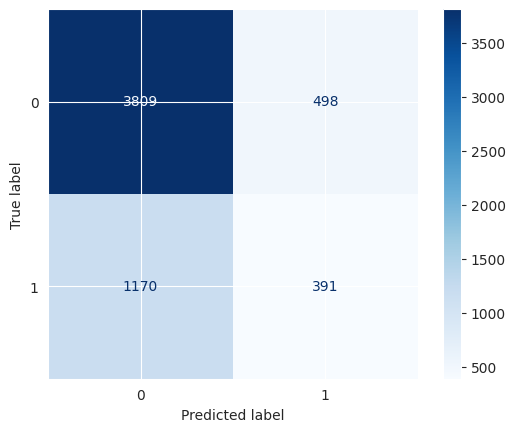

In [12]:
# Exibe a matriz de confusão para o Naive Bayes
print("Matriz de Confusão - Naive Bayes:")
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_nb, cmap='Blues');

## Árvores de Decisão (Decision Trees)

In [13]:
# Define os hiperparâmetros para a Árvore de Decisão
# Corrigido: decicion_tree_hyperparameters -> decision_tree_hyperparameters
decision_tree_hyperparameters = {
    "max_depth": 15, # Profundidade máxima da árvore
    "class_weight": "balanced", # Ajusta os pesos das classes inversamente proporcionais às suas frequências
    "random_state": SEED # Semente para reprodutibilidade
}

# Define os passos de seleção de features para a Árvore de Decisão
feature_selection_steps_dt = Pipeline(
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.9,
                missing_values='ignore',
                selection_method='variance'
            )
        ),
        (
            # Seleciona as top 50 features usando a importância de uma árvore (o random_state do seletor é diferente do SEED global)
            # Para consistência, pode-se usar SEED aqui também se desejado.
            "FeatureSelectionTree", TreeFeatureSelector(k=50, random_state=SEED)
        )
    ]
)

# Define o pipeline de pré-processamento para a Árvore de Decisão
# Nota: StandardScaler geralmente não é necessário para modelos baseados em árvores.
preprocessing_pipeline_dt = Pipeline(
    [
        (
            "FeatureSelection", feature_selection_steps_dt
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01) # Cria features de interação
        )
        # (
        #     "Scaler", StandardScaler() # Comentado, geralmente não necessário
        # )
    ]
)

# Define o pipeline completo para o modelo de Árvore de Decisão
decision_tree_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline_dt
        ),
        (
            # Corrigido: "Cassifier" -> "Classifier"
            "Classifier", DecisionTreeClassifier(
                **decision_tree_hyperparameters
            )
        )
    ]
)

In [14]:
# Treina o pipeline da Árvore de Decisão nos dados de treinamento
decision_tree_pipeline.fit(X_train, y_train)
# Faz predições nos dados de validação
y_pred_dt = decision_tree_pipeline.predict(X_val)

In [15]:
# Imprime o relatório de classificação para a Árvore de Decisão
print("Relatório de Classificação - Árvore de Decisão:")
print(classification_report(y_val, y_pred_dt))

Relatório de Classificação - Árvore de Decisão:
              precision    recall  f1-score   support

           0       0.85      0.78      0.81      4307
           1       0.50      0.62      0.56      1561

    accuracy                           0.74      5868
   macro avg       0.68      0.70      0.68      5868
weighted avg       0.76      0.74      0.74      5868



Matriz de Confusão - Árvore de Decisão:


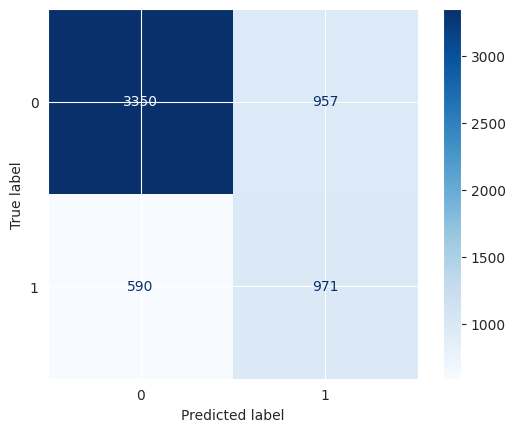

In [16]:
# Exibe a matriz de confusão para a Árvore de Decisão
print("Matriz de Confusão - Árvore de Decisão:")
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_dt, cmap='Blues');

## Regressão Logística

In [17]:
# Define os hiperparâmetros para a Regressão Logística
logistic_regression_hyperparameters = {
    'penalty': 'l2', # Tipo de regularização (L2)
    'C': 1.0, # Inverso da força da regularização (valores menores indicam regularização mais forte)
    'solver': 'lbfgs', # Algoritmo a ser usado no problema de otimização
    'max_iter': 1000, # Número máximo de iterações para convergência
    'class_weight': 'balanced', # Ajusta os pesos das classes
    'random_state': SEED
}

# Define os passos de seleção de features para a Regressão Logística
feature_selection_steps_lr = Pipeline(
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.8, # Limiar de correlação um pouco menor
                missing_values='ignore',
                selection_method='variance'
            )
        ),
        # (
        #     "FeatureSelectionTree", TreeFeatureSelector(k=50, random_state=SEED) # Seleção baseada em árvore comentada
        # )
    ]
)

# Define o pipeline de pré-processamento para a Regressão Logística
# StandardScaler é importante para a Regressão Logística.
preprocessing_pipeline_lr = Pipeline(
    [
        (
            "FeatureSelection", feature_selection_steps_lr
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        ),
        (
            "Scaler", StandardScaler() # Padroniza as features
        )
    ]
)

# Define o pipeline completo para o modelo de Regressão Logística
logistic_regression_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline_lr
        ),
        (
            "Classifier", LogisticRegression(
                **logistic_regression_hyperparameters
            )
        )
    ]
)

In [18]:
# Treina o pipeline da Regressão Logística nos dados de treinamento
logistic_regression_pipeline.fit(X_train, y_train)
# Faz predições nos dados de validação
y_pred_lr = logistic_regression_pipeline.predict(X_val)

In [19]:
# Imprime o relatório de classificação para a Regressão Logística
print("Relatório de Classificação - Regressão Logística:")
print(classification_report(y_val, y_pred_lr))

Relatório de Classificação - Regressão Logística:
              precision    recall  f1-score   support

           0       0.82      0.76      0.79      4307
           1       0.45      0.52      0.48      1561

    accuracy                           0.70      5868
   macro avg       0.63      0.64      0.64      5868
weighted avg       0.72      0.70      0.71      5868



Matriz de Confusão - Regressão Logística:


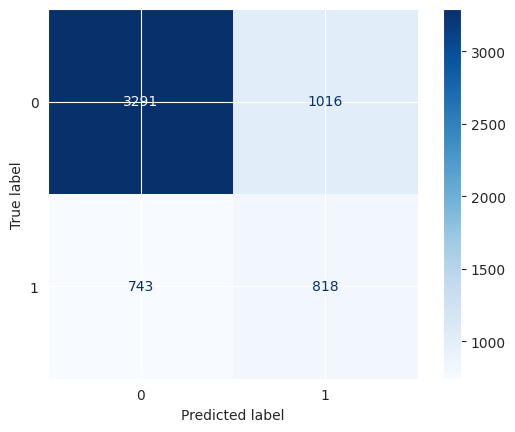

In [20]:
# Exibe a matriz de confusão para a Regressão Logística
print("Matriz de Confusão - Regressão Logística:")
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_lr, cmap='Blues');

## Linear SVC (Support Vector Classifier com Kernel Linear)

In [21]:
# Define os hiperparâmetros para o Linear SVC
linear_svc_hyperparameters = {
    'C': 1.0, # Parâmetro de regularização
    'tol': 1e-4, # Tolerância para o critério de parada
    'max_iter': 2000, # Aumentado para melhor convergência (original era 1000)
    'class_weight': 'balanced',
    'random_state': SEED,
    'dual': False # Recomendado quando n_samples > n_features, pode ajudar na convergência
}

# Define os passos de seleção de features para o Linear SVC
feature_selection_steps_lsvc = Pipeline(
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.8,
                missing_values='ignore',
                selection_method='variance'
            )
        ),
        # (
        #     "FeatureSelectionTree", TreeFeatureSelector(k=50, random_state=SEED)
        # )
    ]
)

# Define o pipeline de pré-processamento para o Linear SVC
# StandardScaler é importante para SVC.
preprocessing_pipeline_lsvc = Pipeline(
    [
        (
            "FeatureSelection", feature_selection_steps_lsvc
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        ),
        (
            "Scaler", StandardScaler()
        )
    ]
)

# Define o pipeline completo para o modelo Linear SVC
linear_svc_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline_lsvc
        ),
        (
            "Classifier", LinearSVC(
                **linear_svc_hyperparameters
            )
        )
    ]
)

In [22]:
# Treina o pipeline Linear SVC nos dados de treinamento
linear_svc_pipeline.fit(X_train, y_train)
# Faz predições nos dados de validação
y_pred_lsvc = linear_svc_pipeline.predict(X_val)

In [23]:
# Imprime o relatório de classificação para o Linear SVC
print("Relatório de Classificação - Linear SVC:")
print(classification_report(y_val, y_pred_lsvc))

Relatório de Classificação - Linear SVC:
              precision    recall  f1-score   support

           0       0.81      0.76      0.79      4307
           1       0.44      0.52      0.48      1561

    accuracy                           0.70      5868
   macro avg       0.63      0.64      0.63      5868
weighted avg       0.72      0.70      0.70      5868



Matriz de Confusão - Linear SVC:


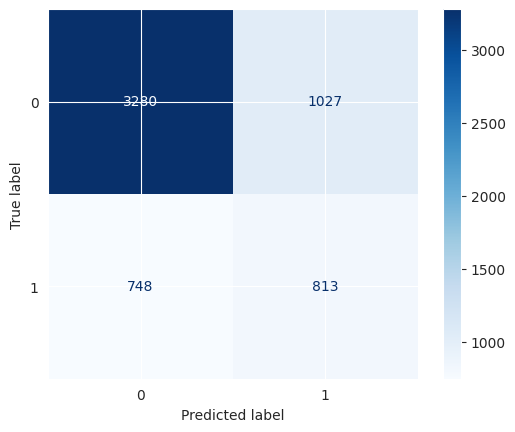

In [24]:
# Exibe a matriz de confusão para o Linear SVC
print("Matriz de Confusão - Linear SVC:")
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_lsvc, cmap='Blues');

## SVM (Support Vector Machine com kernel não linear)

In [25]:
# Define os hiperparâmetros para o SVM com kernel RBF
svm_hyperparameters = {
    'C': 1.0, # Parâmetro de regularização
    'kernel': 'rbf', # Kernel Radial Basis Function
    'gamma': 'scale', # Coeficiente do kernel ('scale' usa 1 / (n_features * X.var()))
    'tol': 1e-3, # Tolerância para o critério de parada
    'max_iter': -1, # Originalmente 15000. -1 significa sem limite, mas pode ser muito lento.
                     # Considere um valor alto ou ajuste C e gamma se houver problemas de convergência.
    'class_weight': 'balanced',
    'random_state': SEED
}

# Define os passos de seleção de features para o SVM
feature_selection_steps_svm = Pipeline(
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.8,
                missing_values='ignore',
                selection_method='variance'
            )
        ),
        (
            # Seleciona as top 30 features. SVMs podem ser sensíveis à dimensionalidade.
            "TreeFeatureSelector", TreeFeatureSelector(k=30, random_state=SEED)
        )
    ]
)

# Define o pipeline de pré-processamento para o SVM
# StandardScaler é importante para SVM.
preprocessing_pipeline_svm = Pipeline(
    [
        (
            "FeatureSelection", feature_selection_steps_svm
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        ),
        (
            "Scaler", StandardScaler()
        )
    ]
)

# Define o pipeline completo para o modelo SVM
svm_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline_svm
        ),
        (
            "Classifier", SVC(
                **svm_hyperparameters
            )
        )
    ]
)

In [26]:
# Treina o pipeline SVM nos dados de treinamento
svm_pipeline.fit(X_train, y_train)
# Faz predições nos dados de validação
y_pred_svm = svm_pipeline.predict(X_val)

In [27]:
# Imprime o relatório de classificação para o SVM
print("Relatório de Classificação - SVM (RBF):")
print(classification_report(y_val, y_pred_svm))

Relatório de Classificação - SVM (RBF):
              precision    recall  f1-score   support

           0       0.83      0.78      0.80      4307
           1       0.48      0.58      0.52      1561

    accuracy                           0.72      5868
   macro avg       0.66      0.68      0.66      5868
weighted avg       0.74      0.72      0.73      5868



Matriz de Confusão - SVM (RBF):


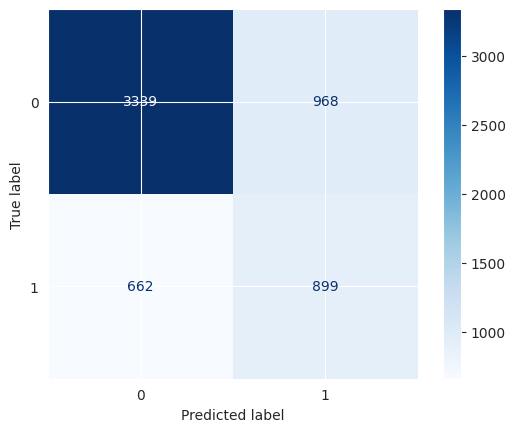

In [28]:
# Exibe a matriz de confusão para o SVM
print("Matriz de Confusão - SVM (RBF):")
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_svm, cmap='Blues');

## Random Forest


In [29]:
# Define os hiperparâmetros para o Random Forest
random_forest_hyperparameters = {
    'n_estimators': 100, # Número de árvores na floresta
    'criterion': 'gini', # Função para medir a qualidade de uma divisão
    'max_depth': 10, # Profundidade máxima de cada árvore
    'min_samples_split': 2, # Número mínimo de amostras necessárias para dividir um nó interno
    'min_samples_leaf': 1, # Número mínimo de amostras necessárias em um nó folha
    'max_features': 'sqrt', # Número de features a considerar ao procurar a melhor divisão ('sqrt' é raiz quadrada do total de features)
    'bootstrap': True, # Se amostras bootstrap são usadas ao construir árvores
    'class_weight': 'balanced', # Ajusta os pesos das classes
    'random_state': SEED
}

# Define os passos de seleção de features para o Random Forest
feature_selection_steps_rf = Pipeline(
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.8,
                missing_values='ignore',
                selection_method='variance'
            )
        ),
        (
            "FeatureSelectionTree", TreeFeatureSelector(k=50, random_state=SEED)
        )
    ]
)

# Define o pipeline de pré-processamento para o Random Forest
# StandardScaler geralmente não é necessário para modelos baseados em árvores como Random Forest.
# No entanto, não prejudicará e pode ser útil se SelectiveInteraction se beneficiar de entradas escalonadas.
preprocessing_pipeline_rf = Pipeline(
    [
        (
            "FeatureSelection", feature_selection_steps_rf
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        ),
        # (
        #     "Scaler", StandardScaler() # Incluído aqui, mas frequentemente opcional para RF
        # )
    ]
)

# Define o pipeline completo para o modelo Random Forest
random_forest_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline_rf
        ),
        (
            "Classifier", RandomForestClassifier(
                **random_forest_hyperparameters
            )
        )
    ]
)

In [30]:
# Treina o pipeline Random Forest nos dados de treinamento
random_forest_pipeline.fit(X_train, y_train)
# Faz predições nos dados de validação
y_pred_rf = random_forest_pipeline.predict(X_val)

In [31]:
# Imprime o relatório de classificação para o Random Forest
print("Relatório de Classificação - Random Forest:")
print(classification_report(y_val, y_pred_rf))

Relatório de Classificação - Random Forest:
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      4307
           1       0.53      0.64      0.58      1561

    accuracy                           0.75      5868
   macro avg       0.70      0.72      0.70      5868
weighted avg       0.77      0.75      0.76      5868



Matriz de Confusão - Random Forest:


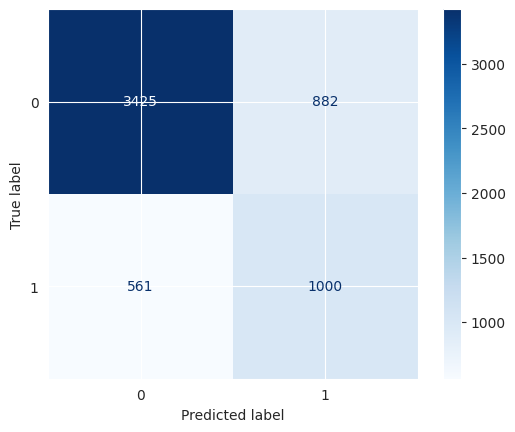

In [32]:
# Exibe a matriz de confusão para o Random Forest
print("Matriz de Confusão - Random Forest:")
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_rf, cmap='Blues');

## AdaBoost (Adaptive Boosting)

In [33]:
# Define os hiperparâmetros para o AdaBoost
adaboost_hyperparameters = {
    # O estimador base é uma árvore de decisão rasa
    'estimator': DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=SEED),
    'n_estimators': 50, # Número de weak learners (estimadores base) a serem treinados
    'learning_rate': 1.0, # Contribuição de cada classificador (peso)
    'random_state': SEED
}

# Define os passos de seleção de features para o AdaBoost
feature_selection_steps_ab = Pipeline(
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.8,
                missing_values='ignore',
                selection_method='variance'
            )
        ),
        (
            "FeatureSelectionTree", TreeFeatureSelector(k=50, random_state=SEED)
        )
    ]
)

# Define o pipeline de pré-processamento para o AdaBoost
# StandardScaler geralmente não é necessário para estimadores baseados em árvores no AdaBoost.
preprocessing_pipeline_ab = Pipeline(
    [
        (
            "FeatureSelection", feature_selection_steps_ab
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        ),
        # (
        #     "Scaler", StandardScaler() # Comentado, geralmente não necessário
        # )
    ]
)

# Define o pipeline completo para o modelo AdaBoost
adaboost_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline_ab
        ),
        (
            "Classifier", AdaBoostClassifier(
                **adaboost_hyperparameters
            )
        )
    ]
)

In [34]:
# Treina o pipeline AdaBoost nos dados de treinamento
adaboost_pipeline.fit(X_train, y_train)
# Faz predições nos dados de validação
y_pred_ab = adaboost_pipeline.predict(X_val)

In [35]:
# Imprime o relatório de classificação para o AdaBoost
print("Relatório de Classificação - AdaBoost:")
print(classification_report(y_val, y_pred_ab))

Relatório de Classificação - AdaBoost:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      4307
           1       0.49      0.52      0.51      1561

    accuracy                           0.73      5868
   macro avg       0.66      0.66      0.66      5868
weighted avg       0.73      0.73      0.73      5868



Matriz de Confusão - AdaBoost:


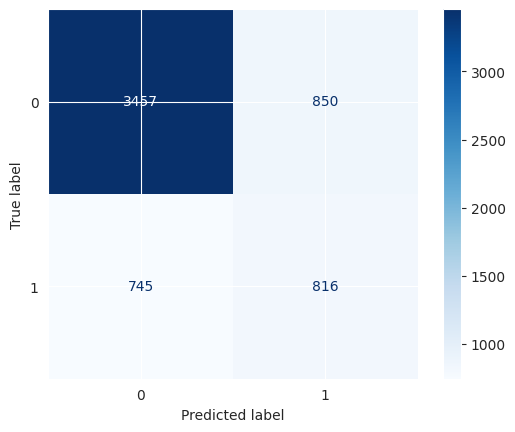

In [36]:
# Exibe a matriz de confusão para o AdaBoost
print("Matriz de Confusão - AdaBoost:")
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_ab, cmap='Blues');

## XGBoost (Extreme Gradient Boosting)


In [37]:
# Define os hiperparâmetros para o XGBoost
xgboost_hyperparameters = {
    "objective": "binary:logistic", # Para classificação binária
    "eval_metric": "aucpr", # Métrica de avaliação: Área sob a Curva Precision-Recall
    "scale_pos_weight": 3, # Controla o balanço dos pesos positivos e negativos, útil para classes desbalanceadas
                           # (valor ideal pode ser sum(negative instances) / sum(positive instances))
    "learning_rate": 0.05, # Taxa de aprendizado (eta)
    "max_depth":6, # Profundidade máxima de uma árvore
    "min_child_weight": 1, # Soma mínima do peso das instâncias (hessian) necessária em um filho
    "gamma": 0.2, # Redução mínima de perda necessária para fazer uma partição adicional (min_split_loss)
    "subsample": 0.8, # Razão de amostragem das instâncias de treinamento
    "colsample_bytree": 0.8, # Razão de amostragem das colunas ao construir cada árvore
    "lambda": 1.0, # Termo de regularização L2 sobre os pesos (reg_lambda)
    "alpha": 0.0, # Termo de regularização L1 sobre os pesos (reg_alpha)
    "n_estimators": 500, # Número de rodadas de boosting (árvores)
    "verbosity": 0, # Originalmente 1. 0 para silenciar mensagens.
    "random_state": SEED
}

# Define os passos de seleção de features para o XGBoost
feature_selection_steps_xgb = Pipeline(
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.7, # Limiar de correlação um pouco mais baixo
                missing_values='ignore',
                selection_method='variance'
            )
        ),
        (
            "FeatureSelectionTree", TreeFeatureSelector(k=50, random_state=SEED)
        )
    ]
)

# Define o pipeline de pré-processamento para o XGBoost
# StandardScaler geralmente não é necessário para XGBoost.
preprocessing_pipeline_xgb = Pipeline(
    [
        (
            "FeatureSelection", feature_selection_steps_xgb
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        )
    ]
)

# Define o pipeline completo para o modelo XGBoost
xgboost_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline_xgb
        ),
        (
            "Classifier", XGBClassifier(
                **xgboost_hyperparameters
            )
        )
    ]
)

In [38]:
# Treina o pipeline XGBoost nos dados de treinamento
# XGBoost pode usar o conjunto de validação para early stopping se configurado
# Ex: .fit(X_train, y_train, Classifier__eval_set=[(X_val, y_val)], Classifier__early_stopping_rounds=10)
xgboost_pipeline.fit(X_train, y_train)
# Faz predições nos dados de validação
y_pred_xgb = xgboost_pipeline.predict(X_val)

In [39]:
# Imprime o relatório de classificação para o XGBoost
print("Relatório de Classificação - XGBoost:")
print(classification_report(y_val, y_pred_xgb))

Relatório de Classificação - XGBoost:
              precision    recall  f1-score   support

           0       0.87      0.77      0.82      4307
           1       0.52      0.69      0.60      1561

    accuracy                           0.75      5868
   macro avg       0.70      0.73      0.71      5868
weighted avg       0.78      0.75      0.76      5868



Matriz de Confusão - XGBoost:


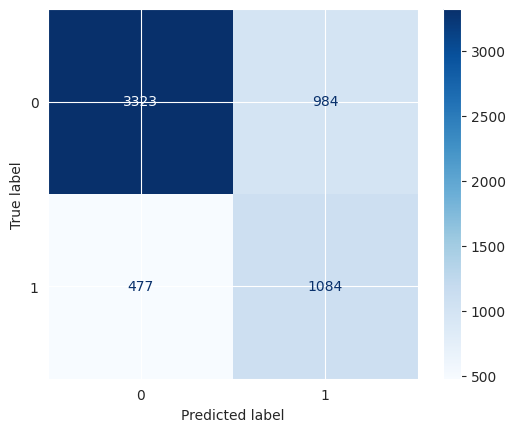

In [40]:
# Exibe a matriz de confusão para o XGBoost
print("Matriz de Confusão - XGBoost:")
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_xgb, cmap='Blues');

## LightGBM (Light Gradient Boosting Machine)


In [41]:
# Define os hiperparâmetros para o LightGBM
lightgbm_hyperparameters = {
    "objective": "binary", # Para classificação binária
    "metric": "aucpr", # Métrica de avaliação
    "is_unbalance": True, # Define como True se o dataset for desbalanceado (alternativa a scale_pos_weight)
    "learning_rate": 0.05,
    "num_leaves": 31, # Número máximo de folhas em uma árvore (valor padrão)
    "max_depth": -1, # Sem limite na profundidade da árvore (padrão)
    "min_child_samples": 20, # Número mínimo de dados necessários em um filho (folha) (padrão)
    "min_child_weight": 1e-3, # Soma mínima do peso das instâncias (hessian) necessária em um filho (folha)
    "subsample": 0.8, # Razão de amostragem das instâncias de treinamento (bagging_fraction)
    "subsample_freq": 1, # Frequência de amostragem (bagging_freq), 0 significa sem amostragem
    "colsample_bytree": 0.8, # Razão de amostragem das colunas ao construir cada árvore (feature_fraction)
    "reg_alpha": 0.0, # Regularização L1 (lambda_l1)
    "reg_lambda": 1.0, # Regularização L2 (lambda_l2)
    "n_estimators": 500,
    "verbosity": -1, # Suprime a saída verbosa (-1 para fatal, 0 para erro/aviso, 1 para info)
    "random_state": SEED
}

# Define os passos de seleção de features para o LightGBM
feature_selection_steps_lgbm = Pipeline(
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.7,
                missing_values='ignore',
                selection_method='variance'
            )
        ),
        (
            "FeatureSelectionTree", TreeFeatureSelector(k=50, random_state=SEED)
        )
    ]
)

# Define o pipeline de pré-processamento para o LightGBM
# StandardScaler geralmente não é necessário para LightGBM.
preprocessing_pipeline_lgbm = Pipeline(
    [
        (
            "FeatureSelection", feature_selection_steps_lgbm
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        )
    ]
)

# Define o pipeline completo para o modelo LightGBM
lightgbm_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline_lgbm
        ),
        (
            "Classifier", LGBMClassifier(
                **lightgbm_hyperparameters
            )
        )
    ]
)

In [42]:
# Treina o pipeline LightGBM nos dados de treinamento
# LightGBM também pode usar eval_set para early stopping
# Ex: .fit(X_train, y_train, Classifier__eval_set=[(X_val, y_val)], Classifier__callbacks=[lgb.early_stopping(10)])
lightgbm_pipeline.fit(X_train, y_train)
# Faz predições nos dados de validação
y_pred_lgbm = lightgbm_pipeline.predict(X_val)

In [43]:
# Imprime o relatório de classificação para o LightGBM
print("Relatório de Classificação - LightGBM:")
print(classification_report(y_val, y_pred_lgbm))

Relatório de Classificação - LightGBM:
              precision    recall  f1-score   support

           0       0.87      0.78      0.82      4307
           1       0.53      0.68      0.59      1561

    accuracy                           0.75      5868
   macro avg       0.70      0.73      0.71      5868
weighted avg       0.78      0.75      0.76      5868



Matriz de Confusão - LightGBM:


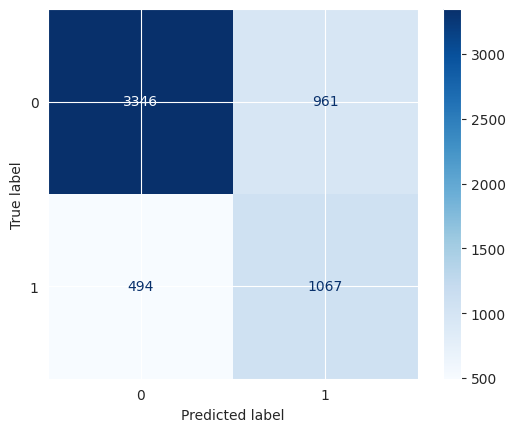

In [44]:
# Exibe a matriz de confusão para o LightGBM
print("Matriz de Confusão - LightGBM:")
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_lgbm, cmap='Blues');

## CatBoost (Categorical Boosting)


In [45]:
# Define os hiperparâmetros para o CatBoost
# Corrigido: catboost_hyperparaters -> catboost_hyperparameters
catboost_hyperparameters = {
    "iterations": 1000, # Número de árvores (equivalente a n_estimators)
    "learning_rate": 0.05,
    "depth": 6, # Profundidade das árvores
    "l2_leaf_reg": 3, # Coeficiente de regularização L2 (lambda)
    "random_strength": 1.5, # Quantidade de aleatoriedade a aplicar aos scores para evitar overfitting em divisões
    "bagging_temperature": 1.0, # Controla a intensidade do bagging (0 para sem bagging, 1 para bagging agressivo)
    "border_count": 128, # Número de divisões para features numéricas (quantização)
    "loss_function": "Logloss", # Função de perda para classificação binária
    "eval_metric": "F1", # Métrica de avaliação para early stopping e logging
    "scale_pos_weight": 3, # Peso para a classe positiva, útil para datasets desbalanceados
    "verbose": 0, # Suprime a saída verbosa durante o treinamento (0 para silêncio)
    "task_type": "CPU", # Usar CPU para treinamento (pode ser "GPU" se disponível e configurado)
    "random_seed": SEED # Semente aleatória
}

# Define os passos de seleção de features para o CatBoost
feature_selection_steps_cat = Pipeline(
    [
        (
            "LowVarianceFeatureSelector", VarianceThreshold(
                threshold=1e-4
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.7,
                missing_values='ignore',
                selection_method='variance'
            )
        ),
        (
            "FeatureSelectionTree", TreeFeatureSelector(k=50, random_state=SEED)
        )
    ]
)

# Define o pipeline de pré-processamento para o CatBoost
# CatBoost pode lidar com features categóricas nativamente e é geralmente robusto ao escalonamento de features.
preprocessing_pipeline_cat = Pipeline(
    [
        (
            "FeatureSelection", feature_selection_steps_cat
        ),
        (
            "SelectiveInteraction", SelectiveInteraction(threshold=0.01)
        )
    ]
)

# Define o pipeline completo para o modelo CatBoost
catboost_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline_cat
        ),
        (
            "Classifier", CatBoostClassifier(
                **catboost_hyperparameters # Corrigido
            )
        )
    ]
)

In [46]:
# Treina o pipeline CatBoost nos dados de treinamento
# CatBoost também pode usar eval_set para early stopping
# Ex: .fit(X_train, y_train, Classifier__eval_set=(X_val, y_val), Classifier__early_stopping_rounds=50)
catboost_pipeline.fit(X_train, y_train) # Adicionar , cat_features=lista_de_features_categoricas se houver
# Faz predições nos dados de validação
y_pred_cat = catboost_pipeline.predict(X_val)

In [47]:
# Imprime o relatório de classificação para o CatBoost
print("Relatório de Classificação - CatBoost:")
print(classification_report(y_val, y_pred_cat))

Relatório de Classificação - CatBoost:
              precision    recall  f1-score   support

           0       0.88      0.76      0.81      4307
           1       0.51      0.70      0.59      1561

    accuracy                           0.74      5868
   macro avg       0.69      0.73      0.70      5868
weighted avg       0.78      0.74      0.75      5868



Matriz de Confusão - CatBoost:


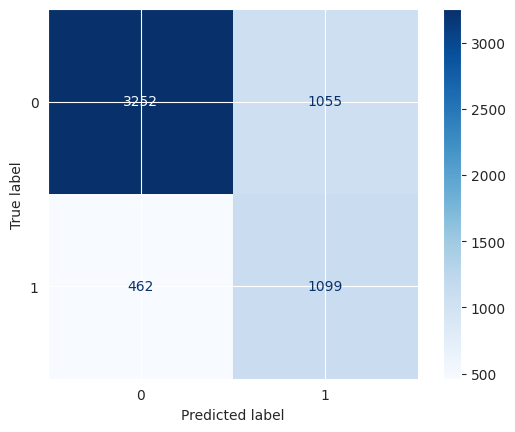

In [48]:
# Exibe a matriz de confusão para o CatBoost
print("Matriz de Confusão - CatBoost:")
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_cat, cmap='Blues');